# Model experiments and selection

This notebook preserves the completed model-selection story: deterministic
split integrity, classical NLP baselines, validation-only confidence routing,
ModernBERT configuration, and the single held-out test result.

Training and final-test evaluation were **not rerun during curation**. Recorded
aggregate values are preserved from the completed experiment and from
`reports/metrics/final_test_results.json`. Complaint narratives are never
previewed.


## Phase 1 ? Load prepared splits and verify integrity

A temporal split was considered first. It was rejected because the current
credit-reporting product had only **18 examples** in the candidate 2026 test
period, making the comparison unstable. The final benchmark therefore uses a
deterministic stratified random 70/15/15 split under a similar data
distribution.

| Split | Rows | Share | Classes |
| --- | ---: | ---: | ---: |
| Train | 78,675 | 70% | 11 |
| Validation | 16,859 | 15% | 11 |
| Test | 16,860 | 15% | 11 |

This design supports model comparison, but it does not prove robustness to
future temporal drift or taxonomy changes.


In [ ]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
SPLIT_DIRECTORY = PROJECT_ROOT / "data" / "processed"
SPLIT_PATHS = {
    "train": SPLIT_DIRECTORY / "train.parquet",
    "validation": SPLIT_DIRECTORY / "validation.parquet",
    "test": SPLIT_DIRECTORY / "test.parquet",
}
MODEL_COLUMNS = ["complaint_id", "date_received", "product", "text"]

train_df = pd.read_parquet(SPLIT_PATHS["train"], columns=MODEL_COLUMNS)
validation_df = pd.read_parquet(
    SPLIT_PATHS["validation"], columns=MODEL_COLUMNS
)
# Test remains unopened until the one recorded final-evaluation phase.

assert len(train_df) == 78_675
assert len(validation_df) == 16_859
assert train_df["product"].nunique() == 11
assert validation_df["product"].nunique() == 11
assert set(train_df["complaint_id"]).isdisjoint(
    set(validation_df["complaint_id"])
)

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [78_675, 16_859, 16_860],
        "share_percent": [70.0, 15.0, 15.0],
        "products": [11, 11, 11],
    }
)
display(split_summary_df)


## Phase 2 ? Classical baseline comparison

Only the complaint `text` column is used as input. `issue` and `sub_issue` are
excluded. Logistic Regression slightly outperformed both LinearSVC variants on
validation macro F1 while retaining confidence scores needed for selective
routing.

| Validation model | Accuracy | Macro F1 | Weighted F1 |
| --- | ---: | ---: | ---: |
| TF-IDF + Logistic Regression | 0.8059 | 0.7879 | 0.8047 |
| TF-IDF + LinearSVC | 0.8047 | 0.7855 | 0.8030 |
| TF-IDF + LinearSVC balanced | 0.8040 | 0.7855 | 0.8033 |
| Dummy most-frequent | 0.1067 | 0.0175 | 0.0206 |

`Debt or credit management` was the weakest Logistic Regression class on
validation (F1 0.5272), which motivates conservative human review.


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 100_000
LOGISTIC_MAX_ITER = 500

baseline_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.98,
                max_features=TFIDF_MAX_FEATURES,
                sublinear_tf=True,
                dtype=np.float32,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                max_iter=LOGISTIC_MAX_ITER,
                random_state=RANDOM_STATE,
                tol=1e-3,
            ),
        ),
    ]
)

baseline_pipeline.fit(train_df["text"], train_df["product"])
validation_predictions = baseline_pipeline.predict(validation_df["text"])

baseline_validation_df = pd.DataFrame(
    {
        "accuracy": [accuracy_score(validation_df["product"], validation_predictions)],
        "macro_f1": [f1_score(validation_df["product"], validation_predictions, average="macro")],
        "weighted_f1": [f1_score(validation_df["product"], validation_predictions, average="weighted")],
    }
)
display(baseline_validation_df)


## Phase 3 ? Exploratory validation confidence routing

Threshold analysis below is **validation-only**. The 0.70 rows were useful for
exploring the coverage/quality curve; they were not the final benchmark
thresholds. Before opening test, the fixed routing thresholds were set to:

- **0.80 for TF-IDF + Logistic Regression**;
- **0.90 for ModernBERT**.

| Threshold | Baseline coverage | Baseline accepted accuracy | ModernBERT coverage | ModernBERT accepted accuracy |
| ---: | ---: | ---: | ---: | ---: |
| 0.50 | 72.8572% | 0.9017 | 90.8239% | 0.8668 |
| 0.60 | 63.3193% | 0.9269 | 85.1949% | 0.8924 |
| 0.70 | 53.1526% | 0.9469 | 79.2870% | 0.9135 |
| 0.80 | 42.3513% | 0.9615 | 72.0387% | 0.9357 |
| 0.90 | 28.3647% | 0.9757 | 60.9763% | 0.9572 |

Scores are model confidence values, not calibrated probabilities.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

CONFIDENCE_THRESHOLDS = [0.00, 0.50, 0.60, 0.70, 0.80, 0.90]
FIXED_BASELINE_THRESHOLD = 0.80
FIXED_TRANSFORMER_THRESHOLD = 0.90

validation_probabilities = baseline_pipeline.predict_proba(validation_df["text"])
validation_confidences = validation_probabilities.max(axis=1)
validation_predictions = baseline_pipeline.classes_[
    validation_probabilities.argmax(axis=1)
]

policy_rows = []
for threshold in CONFIDENCE_THRESHOLDS:
    accepted = validation_confidences >= threshold
    policy_rows.append(
        {
            "confidence_threshold": threshold,
            "automation_coverage_percent": accepted.mean() * 100,
            "accuracy_on_automated_cases": accuracy_score(
                validation_df.loc[accepted, "product"],
                validation_predictions[accepted],
            ),
            "macro_f1_on_automated_cases": f1_score(
                validation_df.loc[accepted, "product"],
                validation_predictions[accepted],
                average="macro",
                zero_division=0,
            ),
        }
    )

baseline_confidence_policy_df = pd.DataFrame(policy_rows)
display(baseline_confidence_policy_df)


## Phase 4 ? ModernBERT configuration and recorded validation result

ModernBERT was selected using validation macro F1, before test was opened.
Training used `answerdotai/ModernBERT-base`, 512-token inputs, two epochs, a
2e-5 learning rate, weight decay 0.01, warmup ratio 0.10, bfloat16 on the local
CUDA system, and best-checkpoint selection by validation macro F1.

| Validation result | Logistic Regression | ModernBERT |
| --- | ---: | ---: |
| Accuracy | 0.8059 | 0.8187 |
| Macro F1 | 0.7879 | 0.7997 |
| Deployment size in recorded environment | 5.1020 MB | 289.0646 MB |

ModernBERT improved quality and routing coverage. Logistic Regression remained
much smaller and faster. Runtime and size observations are environment-specific
and are not universal guarantees.


In [ ]:
TRANSFORMER_CONFIG = {
    "model_id": "answerdotai/ModernBERT-base",
    "max_length": 512,
    "train_batch_size": 8,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 4,
    "epochs": 2,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "selection_metric": "validation macro F1",
}

recorded_validation_results_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "validation_accuracy": 0.8059,
            "validation_macro_f1": 0.7879,
        },
        {
            "model": "ModernBERT-base 512",
            "validation_accuracy": 0.8187,
            "validation_macro_f1": 0.7997,
        },
    ]
)
display(pd.Series(TRANSFORMER_CONFIG, name="value").to_frame())
display(recorded_validation_results_df)


## Phase 5 ? Recorded held-out test results

The test set was opened once after model and threshold selection. This phase
loads the immutable aggregate JSON; it does not load test rows, predictions, or
models and must not be used for further tuning.


In [ ]:
FINAL_METRICS_PATH = (
    PROJECT_ROOT / "reports" / "metrics" / "final_test_results.json"
)

with FINAL_METRICS_PATH.open(encoding="utf-8") as metrics_file:
    final_metrics = json.load(metrics_file)

assert final_metrics["model_selected_before_test"] == "ModernBERT-base 512"
assert final_metrics["baseline_fixed_threshold"] == FIXED_BASELINE_THRESHOLD
assert final_metrics["transformer_fixed_threshold"] == FIXED_TRANSFORMER_THRESHOLD

final_model_comparison_df = pd.DataFrame(final_metrics["global_test_results"])
final_policy_comparison_df = pd.DataFrame(
    final_metrics["selective_routing_test_results"]
)
display(final_model_comparison_df)
display(final_policy_comparison_df)


### Immutable final comparison

| Held-out test result | Logistic Regression | ModernBERT |
| --- | ---: | ---: |
| Accuracy | 0.8015 | 0.8222 |
| Macro F1 | 0.7837 | 0.8040 |
| Weighted F1 | 0.8001 | 0.8209 |
| Fixed threshold | 0.80 | 0.90 |
| Automation coverage | 42.6216% | 61.0320% |
| Accuracy on automatically routed cases | 0.9641 | 0.9587 |
| Macro F1 on automatically routed cases | 0.9390 | 0.9413 |

ModernBERT automatically routed 10,290 of 16,860 held-out complaints; 6,570
were sent to manual review. This is potential operational value under benchmark
conditions, not a measured workload reduction in a real institution.

### Recorded class-level F1

| Product | Baseline F1 | ModernBERT F1 |
| --- | ---: | ---: |
| Payday loan, title loan, personal loan, or advance loan | 0.7447 | 0.8012 |
| Debt or credit management | 0.5288 | 0.5582 |
| Vehicle loan or lease | 0.8453 | 0.8727 |
| Credit card | 0.7856 | 0.8122 |
| Checking or savings account | 0.7565 | 0.7818 |
| Prepaid card | 0.8237 | 0.8435 |
| Money transfer, virtual currency, or money service | 0.7698 | 0.7889 |
| Mortgage | 0.9247 | 0.9382 |
| Credit reporting or other personal consumer reports | 0.7739 | 0.7804 |
| Student loan | 0.9374 | 0.9414 |
| Debt collection | 0.7304 | 0.7254 |


### What the held-out comparison means

The first chart compares overall classification quality on the immutable
held-out benchmark. The second separates two operational policy outcomes:
routing coverage and accuracy within the automatically routed subset.
ModernBERT increases coverage by **18.4104 percentage points** while retaining
approximately 96% accepted-case accuracy. Confidence scores are not calibrated
probabilities.

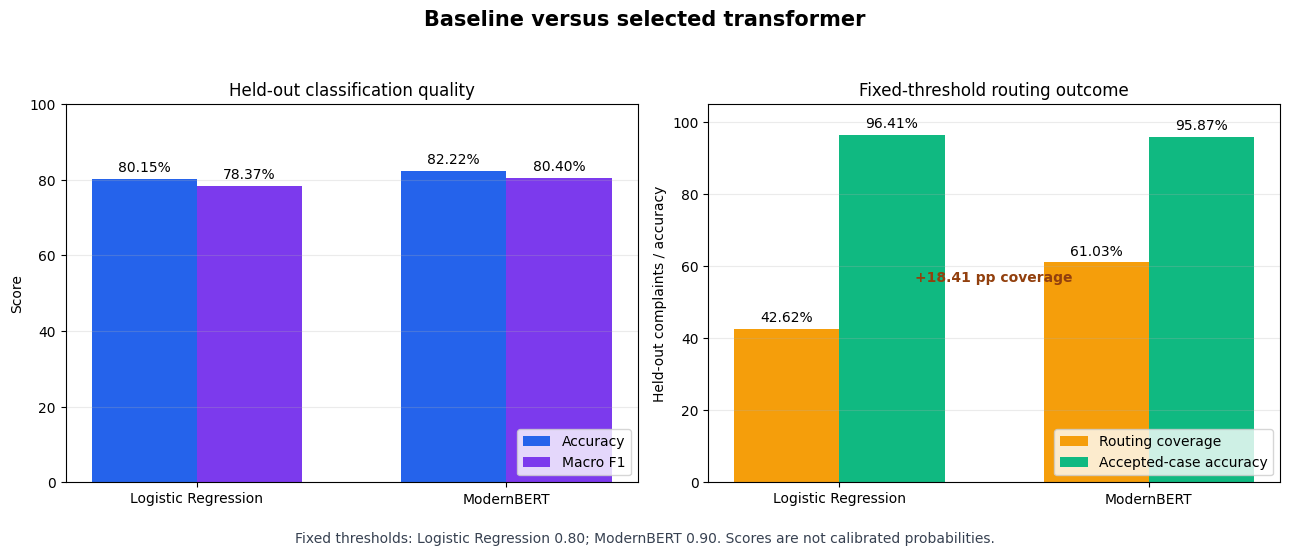

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


project_root = find_project_root(Path.cwd())
metrics_path = project_root / "reports" / "metrics" / "final_test_results.json"
with metrics_path.open(encoding="utf-8") as metrics_file:
    recorded_metrics = json.load(metrics_file)

models = ["Logistic Regression", "ModernBERT"]
global_results = recorded_metrics["global_test_results"]
routing_results = recorded_metrics["selective_routing_test_results"]
accuracy = [row["test_accuracy"] * 100 for row in global_results]
macro_f1 = [row["test_macro_f1"] * 100 for row in global_results]
coverage = [row["automation_coverage_percent"] for row in routing_results]
accepted_accuracy = [
    row["accuracy_on_automated_cases"] * 100
    for row in routing_results
]

positions = np.arange(len(models))
width = 0.34
figure, axes = plt.subplots(1, 2, figsize=(13, 5.5))

quality_accuracy = axes[0].bar(
    positions - width / 2,
    accuracy,
    width,
    label="Accuracy",
    color="#2563EB",
)
quality_macro_f1 = axes[0].bar(
    positions + width / 2,
    macro_f1,
    width,
    label="Macro F1",
    color="#7C3AED",
)
axes[0].bar_label(quality_accuracy, fmt="%.2f%%", padding=3)
axes[0].bar_label(quality_macro_f1, fmt="%.2f%%", padding=3)
axes[0].set_title("Held-out classification quality")
axes[0].set_xticks(positions, models)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 100)
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", alpha=0.25)

routing_coverage = axes[1].bar(
    positions - width / 2,
    coverage,
    width,
    label="Routing coverage",
    color="#F59E0B",
)
routing_accuracy = axes[1].bar(
    positions + width / 2,
    accepted_accuracy,
    width,
    label="Accepted-case accuracy",
    color="#10B981",
)
axes[1].bar_label(routing_coverage, fmt="%.2f%%", padding=3)
axes[1].bar_label(routing_accuracy, fmt="%.2f%%", padding=3)
axes[1].set_title("Fixed-threshold routing outcome")
axes[1].set_xticks(positions, models)
axes[1].set_ylabel("Held-out complaints / accuracy")
axes[1].set_ylim(0, 105)
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", alpha=0.25)
axes[1].text(
    0.5,
    0.53,
    "+18.41 pp coverage",
    transform=axes[1].transAxes,
    ha="center",
    fontweight="bold",
    color="#92400E",
)

figure.suptitle("Baseline versus selected transformer", fontsize=15, fontweight="bold")
figure.text(
    0.5,
    0.01,
    "Fixed thresholds: Logistic Regression 0.80; ModernBERT 0.90. Scores are not calibrated probabilities.",
    ha="center",
    color="#374151",
)
figure.tight_layout(rect=(0, 0.05, 1, 0.94))
plt.show()


### Where model quality remains uneven

The recorded per-class F1 comparison shows that ModernBERT improves most
classes, but `Debt or credit management` remains the weakest category and
`Debt collection` does not improve. This is why aggregate gains do not remove
the need for class-aware review and monitoring.

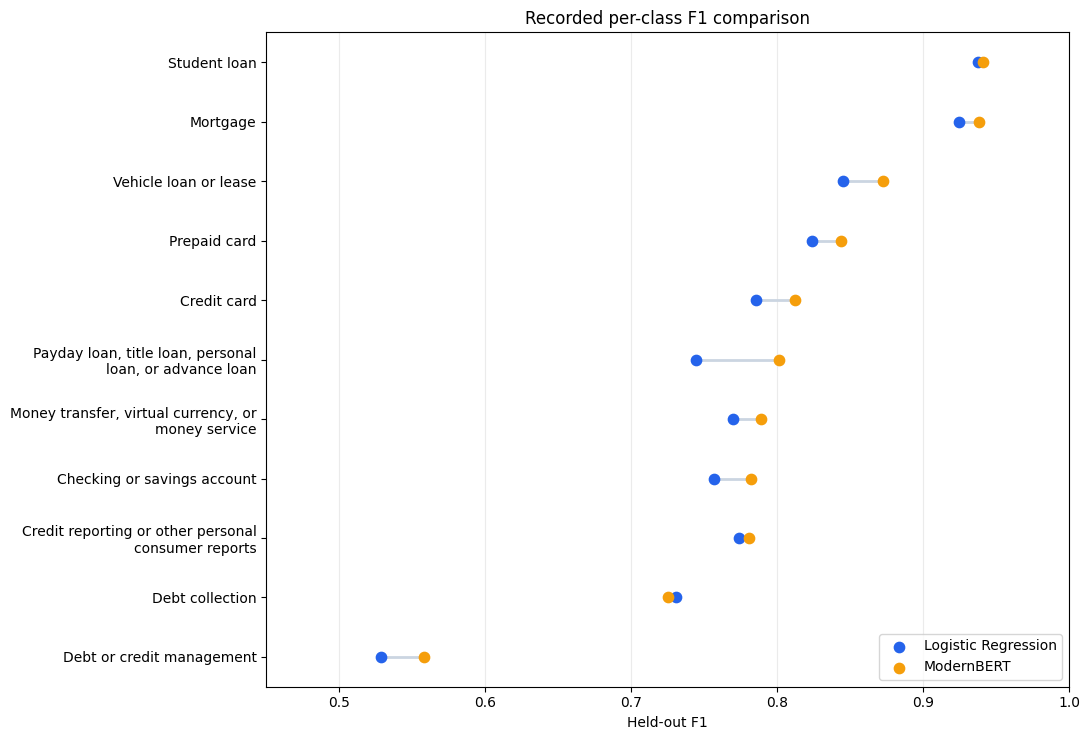

In [1]:
import textwrap

import matplotlib.pyplot as plt

RECORDED_CLASS_F1 = [
    ("Payday loan, title loan, personal loan, or advance loan", 0.7447, 0.8012),
    ("Debt or credit management", 0.5288, 0.5582),
    ("Vehicle loan or lease", 0.8453, 0.8727),
    ("Credit card", 0.7856, 0.8122),
    ("Checking or savings account", 0.7565, 0.7818),
    ("Prepaid card", 0.8237, 0.8435),
    ("Money transfer, virtual currency, or money service", 0.7698, 0.7889),
    ("Mortgage", 0.9247, 0.9382),
    ("Credit reporting or other personal consumer reports", 0.7739, 0.7804),
    ("Student loan", 0.9374, 0.9414),
    ("Debt collection", 0.7304, 0.7254),
]

ordered_class_f1 = sorted(RECORDED_CLASS_F1, key=lambda row: row[2])
products = [textwrap.fill(row[0], width=38) for row in ordered_class_f1]
baseline_f1 = [row[1] for row in ordered_class_f1]
modernbert_f1 = [row[2] for row in ordered_class_f1]
positions = range(len(products))

figure, axis = plt.subplots(figsize=(11, 7.5))
for position, baseline, modernbert in zip(positions, baseline_f1, modernbert_f1):
    axis.plot([baseline, modernbert], [position, position], color="#CBD5E1", linewidth=2)
axis.scatter(baseline_f1, positions, label="Logistic Regression", color="#2563EB", s=55, zorder=3)
axis.scatter(modernbert_f1, positions, label="ModernBERT", color="#F59E0B", s=55, zorder=3)
axis.set_yticks(list(positions), products)
axis.set_xlim(0.45, 1.0)
axis.set_xlabel("Held-out F1")
axis.set_title("Recorded per-class F1 comparison")
axis.grid(axis="x", alpha=0.25)
axis.legend(loc="lower right")
figure.tight_layout()
plt.show()


## Phase 6 ? Conclusions and limitations

- ModernBERT was selected on validation macro F1 and provides better overall
  quality and higher automation coverage than the classical baseline.
- Logistic Regression remains a strong, much smaller and faster comparison.
- Confidence scores are uncalibrated; threshold routing manages uncertainty but
  does not eliminate mistakes.
- Inputs longer than 512 tokens are truncated.
- `Debt or credit management` remains the most difficult class.
- The stratified benchmark does not prove robustness to temporal drift or
  future taxonomy changes.
- No fairness or subgroup analysis has been completed.
- The system has not been evaluated inside a real financial institution and is
  intended only for routing support, not financial decision-making.
